In [73]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sb
import math
import numpy as np
import itertools

In [74]:
pd.read_csv("/data/cctm/youn/human_microbiome_compendium/projects.csv", sep=",")

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
0,PRJDB11894,https://doi.org/10.1038/s41586-021-03832-5,v1-v2,359.11,False,NaN,stool,healthy,cenenarians & relatives,NaN
1,PRJDB11845,https://doi.org/10.3390/cancers13133332,v1-v2,359.32,True,GENE STAR PI-480,saliva and stool,colorectal cancer + healthy controls,adults aged above 40,Robo-protocol includes beads https://www.kurab...
2,PRJDB8511,https://doi.org/10.3390/nu14173468,v1-v2,276.61,True,in-house,stool,healthy,adults,NaN
3,PRJDB10528,https://doi.org/10.1038/s41467-022-32015-7,v3-v4,389.77,True,automatic nucleic acid extraction system,stool,type 2 diabetes,adults,automated extraction system: Gene Prep Star PI...
4,PRJDB10527,https://doi.org/10.1186/s12866-021-02215-0,v3-v4,274.78,True,Gene Prep Star PI-480 device (Kurabo Industries),stool,healthy,adults,NaN
...,...,...,...,...,...,...,...,...,...,...
477,PRJNA290926,https://doi.org/10.1186/s13073-016-0290-3,v4,205.02,True,PowerSoil-htp 96 Well Soil DNA isolation kit (...,stool,CRC,patients and healthy controls,primers and seq strategy previously described ...
478,PRJNA279031,https://doi.org/10.2147/ceg.s89999,NaN,395.32,True,FastDNA SPIN Kit,stool,Rifaximin treatment for IBS-C,IBS-C patients,primers previously described here https://acad...
479,PRJNA259224,https://doi.org/10.1016/j.chom.2015.01.015,v4,252.78,True,MPBio Fast DNA,"stool, mucosal, lumenal",NaN,Rhesus macaque,NaN
480,PRJNA275256,https://doi.org/10.3164/jcbn.15-148,v4-v5,371.20,True,"EZNA DNA Kit (Omega Bio-tek, Norcross, GA)",stool,persistent diarrhea,children,NaN


In [75]:
def eval_results(dset_name: str, analysis_name: str):
    results_dir = Path("results") / dset_name / analysis_name
    eval_result_dfs = []
    test_df = pd.read_csv(
        Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium") / dset_name / "analyses" / analysis_name / "test.tsv",
        sep='\t',
    )
    proj_metadata = pd.read_csv("/data/cctm/youn/human_microbiome_compendium/projects.csv", sep=",")
    
    # baseline methods
    method_idx_for_color = 0
    for baseline_name in baseline_methods:
        tsv_path = results_dir / f"{baseline_name}.tsv"
        if not tsv_path.exists():
            print("Baseline result tsv does not exist: {}".format(tsv_path))
            continue
        method_name = baseline_name
        eval_result_dfs.append(
            pd.read_csv(tsv_path, sep='\t').assign(
                Method=method_name
            )
        )
    
    # torch models
    for embed_model in embed_models:
        for pred_idx, pred_model in enumerate(pred_models):
            tsv_path = results_dir / f"{embed_model}__{pred_model}.tsv"
            if not tsv_path.exists():
                print("Torch result tsv does not exist: {}".format(tsv_path))
                continue
            
            method_name = f'{embed_model}:{pred_model}'
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name
                )
            )
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    eval_result_df = eval_result_df.merge(
        test_df[['srs', 'project']],
        how='left',
        left_on='SampleId', right_on='srs'
    ).merge(
        proj_metadata[['project', 'avg_length']],
        how='left',
        left_on='project', right_on='project'
    )
    return eval_result_df

In [76]:
embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl', 'epc_nopool_kl']
baseline_methods = ['uniform', 'asv_nearest_neighbor']
# baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]

In [77]:
full_df = eval_results("v3v4_split_multiproj_extended", "random_split")
v3v4_ablated_df = eval_results("v3v4_split_multiproj_extended", "data_ablation_v3v4")
proj_ids = {"PRJNA726866", "PRJNA622517", "PRJNA540406", "PRJNA625181", "PRJNA642894", "PRJEB33905", "PRJEB31155", "PRJNA600229", "PRJNA644097"}

full_df = full_df.loc[full_df['project'].isin(proj_ids)]

Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/dnabert-s__epc_nopool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo-1-8k-base_hyena5__epc_pool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo-1-8k-base_hyena5__epc_pool_3_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo-1-8k-base_hyena5__epc_nopool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo2_7b_hyena10__epc_pool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo2_7b_hyena10__epc_pool_3_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo2_7b_hyena10__epc_nopool_kl.tsv


In [79]:
sample_ids_1 = set(full_df['SampleId'])
sample_ids_2 = set(v3v4_ablated_df['SampleId'])
assert sample_ids_1 == sample_ids_2, "FATAL ERROR: both evaluations must be on the same test samples."

common_sids = sample_ids_1
both_df = pd.concat([
    full_df.assign(Trainset='Full'),
    v3v4_ablated_df.assign(Trainset='Ablated')
], axis=0, ignore_index=True)

display(both_df)

,SampleId,KL_err,RMSL_err,SpearmanCorr,BrayCurtis,RootJensenShannon,NumSGB,Method,srs,project,avg_length,Trainset
0,ERS3136839,0.943344,0.952991,NaN,0.524830,0.463569,43,uniform,ERS3136839,PRJEB31155,402.95,Full
1,ERS3645172,1.103408,0.899484,NaN,0.612160,0.498446,139,uniform,ERS3645172,PRJEB33905,401.41,Full
2,ERS3644690,1.182785,0.871708,NaN,0.590619,0.495556,225,uniform,ERS3644690,PRJEB33905,401.41,Full
3,ERS3644789,1.644498,1.002291,NaN,0.631505,0.544583,169,uniform,ERS3644789,PRJEB33905,401.41,Full
4,ERS3644450,1.101595,0.930212,NaN,0.596723,0.494693,130,uniform,ERS3644450,PRJEB33905,401.41,Full
...,...,...,...,...,...,...,...,...,...,...,...,...
8608,SRS8850527,0.133705,0.272003,0.469444,0.207855,0.184138,173,evo2_7b_hyena10:epc_nopool_kl,SRS8850527,PRJNA726866,414.64,Ablated
8609,SRS8850413,0.138827,0.282780,0.450629,0.207635,0.185833,130,evo2_7b_hyena10:epc_nopool_kl,SRS8850413,PRJNA726866,414.64,Ablated
8610,SRS8850437,0.125310,0.343236,0.640429,0.189270,0.185036,94,evo2_7b_hyena10:epc_nopool_kl,SRS8850437,PRJNA726866,414.64,Ablated
8611,SRS8850394,0.144200,0.304240,0.492455,0.210523,0.193480,200,evo2_7b_hyena10:epc_nopool_kl,SRS8850394,PRJNA726866,414.64,Ablated


In [80]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, x, y, sample_col, hue_order, annot_pvals: bool = False, ax=None, palette=None, correction='fdr_bh'):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=x, y=y, hue=hue, data=data, ax=ax, palette=palette, legend=False, showfliers=False, dodge=True, hue_order=hue_order)
    sb.stripplot(x=x, y=y, hue=hue, data=data, ax=ax, palette=palette, alpha=0.5, edgecolor='black', linewidth=1.0, dodge=True, hue_order=hue_order)
    
    plt.tight_layout()
    return ax

In [81]:
full_df.columns

Index(['SampleId', 'KL_err', 'RMSL_err', 'SpearmanCorr', 'BrayCurtis',
       'RootJensenShannon', 'NumSGB', 'Method', 'srs', 'project',
       'avg_length'],
      dtype='object')

<Axes: xlabel='Method', ylabel='KL_err'>

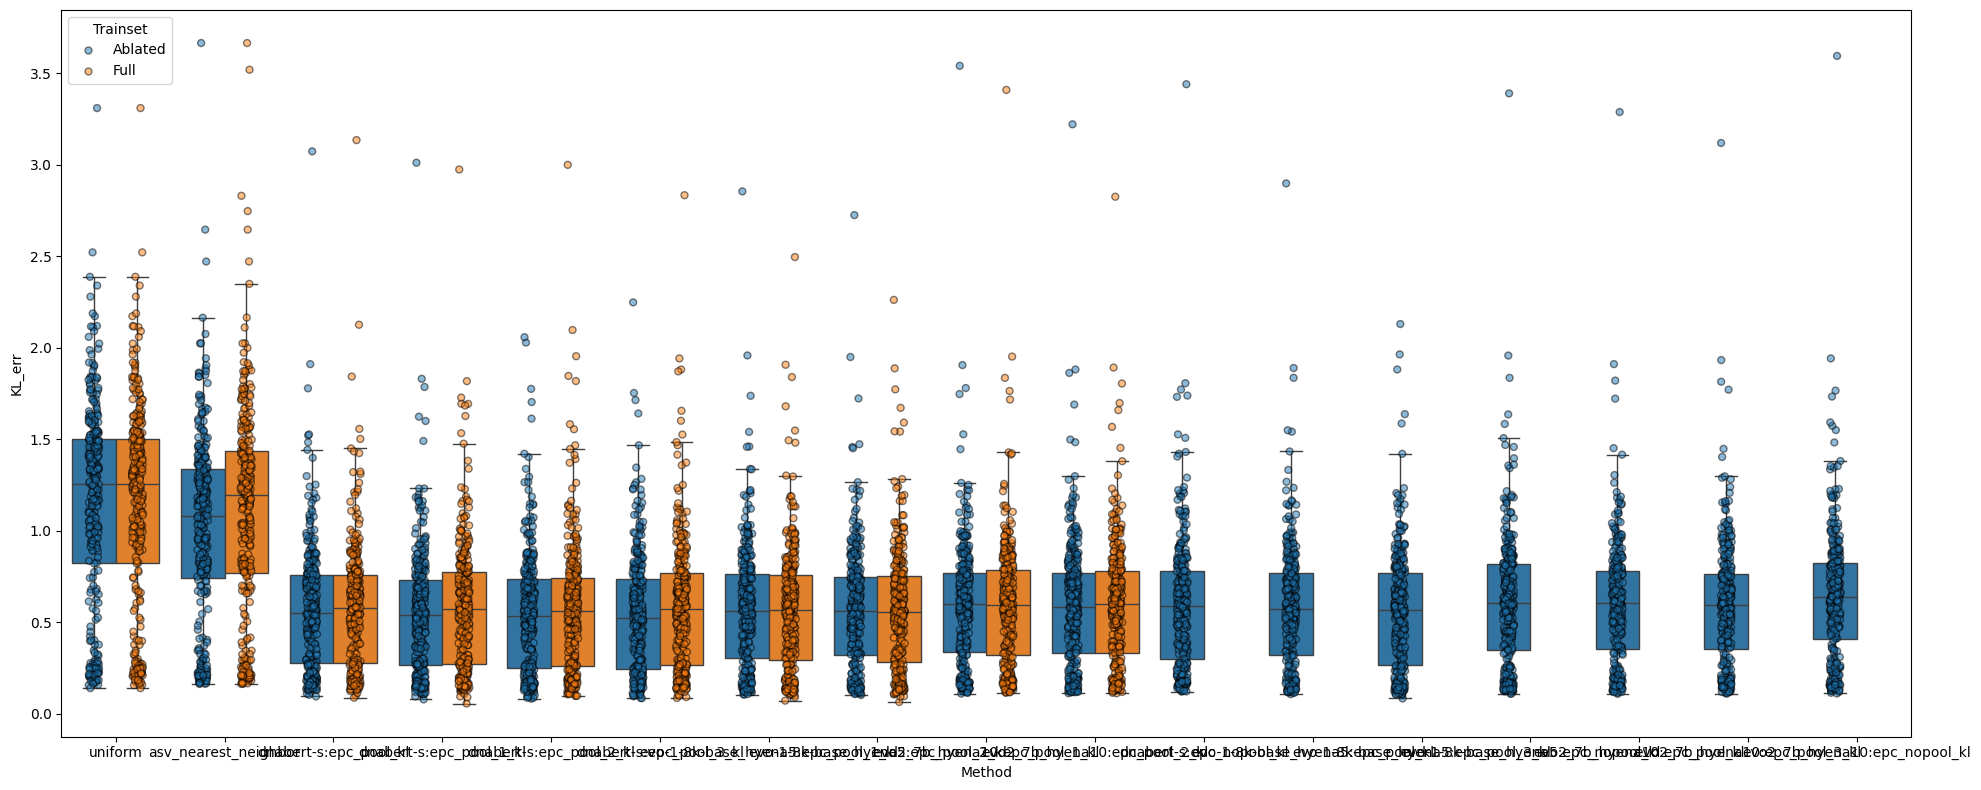

In [82]:
# color_arr = sb.color_palette("Paired", 30)
# method_order = []
# plot_palette = {}
# color_iter = iter(color_arr)
# for embed_mdl in embed_models:
#     for pred_mdl in pred_models:
#         m1 = f'{embed_mdl}:{pred_mdl}_FULL'
#         m2 = f'{embed_mdl}:{pred_mdl}_ABLATED'
#         method_order += [m1, m2]
#         plot_palette[m1] = 'tab:blue'
#         plot_palette[m2] = 'tab:orange'
        
# embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
# pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl', 'epc_nopool_kl']

fig, ax = plt.subplots(1, 1, figsize=(20, 8))
boxplot_with_paired_significance(
    both_df, x='Method', hue='Trainset', y='KL_err', sample_col='SampleId', palette={'Ablated': 'tab:blue', 'Full': 'tab:orange'}, hue_order=['Ablated', 'Full'], ax=ax
)